<a href="https://colab.research.google.com/github/anandaarthy8822/DataAnalysisProject/blob/main/diabetes_risk_prediction_and_healthcare_analytics_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Diabetes Risk Prediction & Healthcare Analytics
End-to-end project: data → analysis → modeling → evaluation → insights

##  Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

##  Load Dataset

In [ ]:
df = pd.read_csv('/content/sample_data/diabetes_dataset_with_notes.csv')
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


##  Dataset Overview

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


##  Data Cleaning

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

##  Encoding Categorical Variables

In [ ]:
df = pd.get_dummies(df, columns=['gender','smoking_history'], drop_first=True)

##  Exploratory Data Analysis

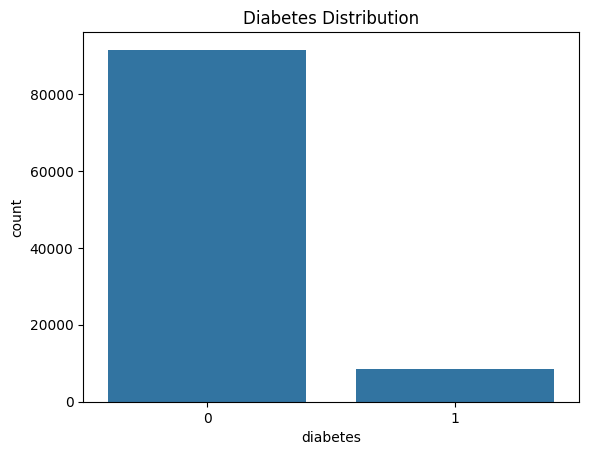

In [ ]:
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

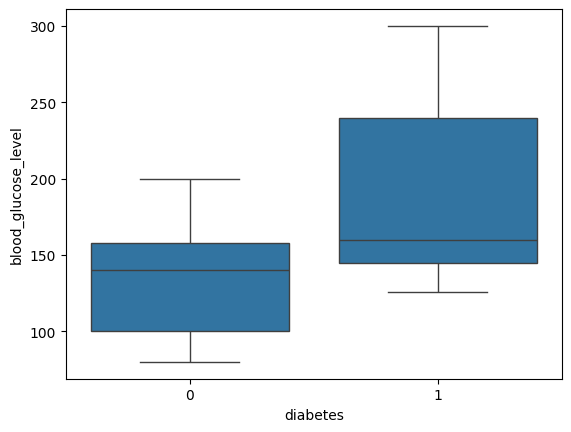

In [ ]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.show()

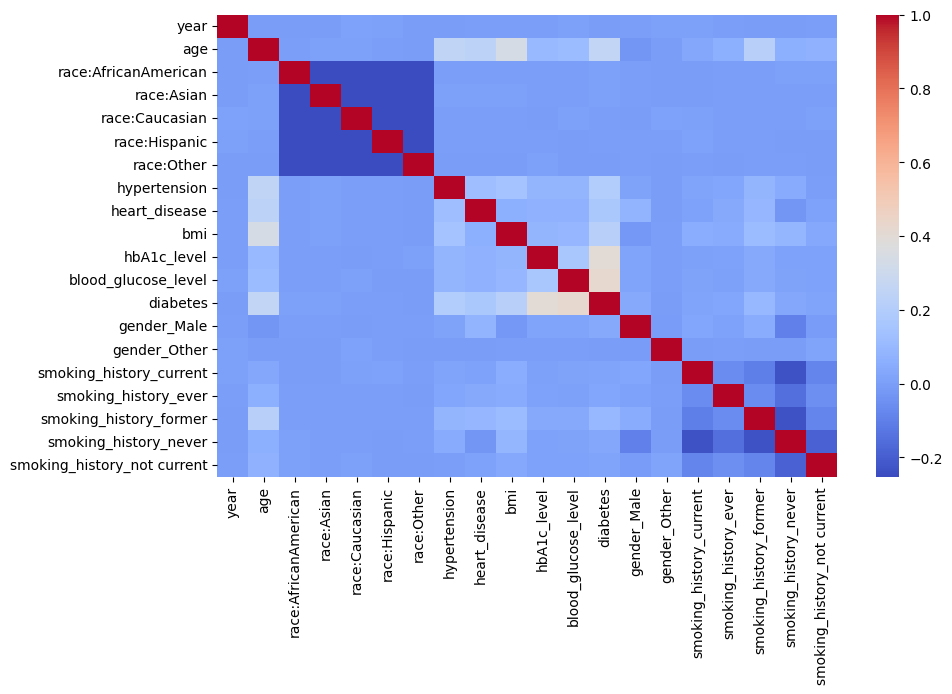

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['location', 'clinical_notes'], errors='ignore').corr(), cmap='coolwarm')
plt.show()

##  Feature Engineering

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

##  Scaling

In [ ]:
scaler = StandardScaler()
# Drop non-numeric columns from X before scaling, as StandardScaler requires numerical input
X_numeric = X.drop(columns=['location', 'clinical_notes'], errors='ignore')
X_scaled = scaler.fit_transform(X_numeric)

##  Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

## Logistic Regression Model

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.96115
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.87      0.63      0.74      1703

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



##  Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9712
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.98      0.68      0.80      1703

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



## Confusion Matrix

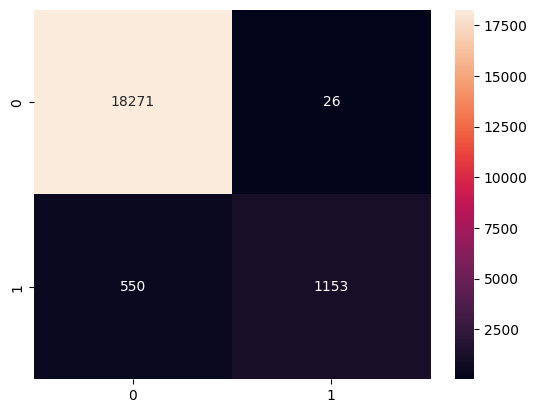

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## 📈 ROC Curve Comparison

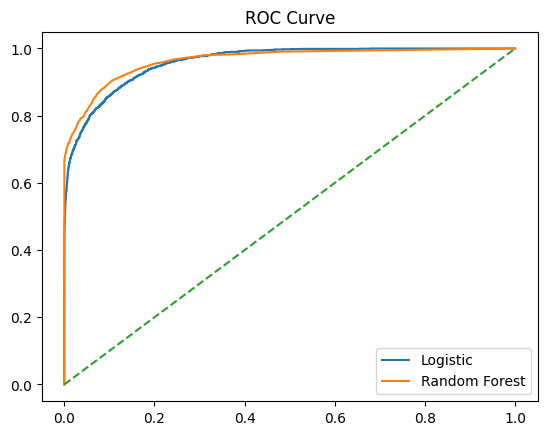

Logistic AUC: 0.9607051279644334
RF AUC: 0.9654189432785348


In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label='Logistic')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve")
plt.show()

print("Logistic AUC:", roc_auc_score(y_test, y_prob_log))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

##  Feature Importance

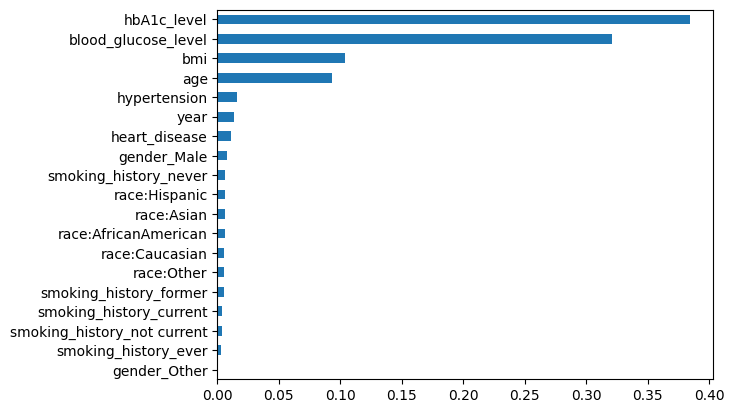

In [ ]:
importance = pd.Series(rf_model.feature_importances_, index=X_numeric.columns)
importance.sort_values().plot(kind='barh')
plt.show()

##  Export for Dashboard

In [ ]:
df['prediction'] = rf_model.predict(X_scaled)
df.to_csv("dashboard_data.csv", index=False)

**bold text**##  Key Insights
- Blood glucose and HbA1c are strongest predictors
- Higher BMI increases diabetes risk
- Age and hypertension are significant contributors
- Random Forest outperforms Logistic Regression